## RetentionAI — 03. Exploratory Data Analysis

**Objective:** test specific, domain-driven hypotheses about *why* customers
churn — not run a generic column-by-column sweep.

**Rule for this notebook:** every hypothesis below (H1–H5) is written
*before* running the cell that tests it. That order matters — writing the
story after seeing the plot is how false patterns get explained away as if
they were predicted. No feature engineering or modeling decisions happen
here; findings are recorded, decisions on what to do with them are deferred
to the next stage.

> Run on the real Kaggle dataset (`data/raw/telco_churn.csv`).

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

from src.config import RAW_CSV_PATH

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [16]:
df = pd.read_csv(RAW_CSV_PATH)

assert df.shape == (7043, 21), f"Expected the real Kaggle shape, got {df.shape}"

# print("Loaded:", RAW_CSV_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### 0. Carrying forward Stage 3 decisions (not re-deciding them)

Two cleaning decisions were already made and justified in
`02_data_understanding.ipynb`:

1. `TotalCharges` is blank (not NaN — an actual space character) for the 11
   customers with `tenure == 0`. They haven't been billed yet, so the blank
   means `0`, not "unknown" — filling with the column mean would invent a
   charge that was never billed.
2. `Churn` needs a numeric encoding so it can actually appear in a
   correlation matrix — leaving it as `"Yes"`/`"No"` means
   `select_dtypes(include="number")` silently drops the one column that
   matters most.

Both are applied here without re-litigating them — this notebook is about
testing hypotheses, not re-auditing data quality.

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["Churn_numeric"] = (df["Churn"] == "Yes").astype(int)

print("Blank TotalCharges remaining:", df["TotalCharges"].isna().sum())
print("Overall churn rate: {:.1%}".format(df["Churn_numeric"].mean()))

Blank TotalCharges remaining: 0
Overall churn rate: 26.5%


### 1. Hypotheses (written before any plot)

- **H1 — Contract type:** month-to-month customers churn more than
  one/two-year customers, because there's no penalty for leaving.
- **H2 — Support add-ons:** customers without `TechSupport` or
  `OnlineSecurity` churn more, because unresolved friction pushes them out.
  (Restricted to customers who *have* internet — see note in H2.)
- **H3 — Tenure:** newer customers churn more than long-tenured ones, and
  the relationship is likely non-linear (steep early, flattening later).
- **H4 — Monthly charges:** customers paying more per month churn more
  (price sensitivity).
- **H5 — Internet service type:** fiber optic customers churn more than
  DSL customers (pricing or reliability complaints).

### 2. H1 — Contract type

**Test:** churn rate per contract type, chi-square test of independence.

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_numeric, dtype: float64

chi2 = 1184.60, p = 5.863e-258


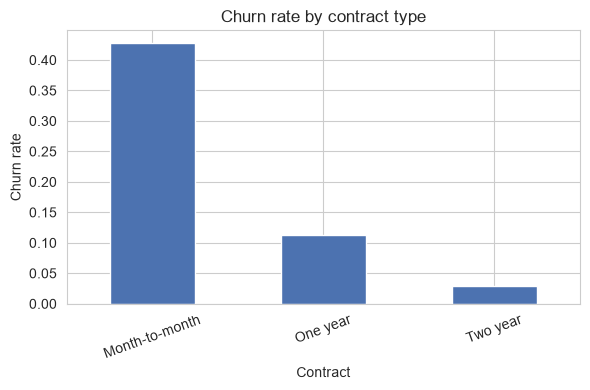

In [18]:
contract_rates = df.groupby("Contract")["Churn_numeric"].mean().sort_values(ascending=False)
print(contract_rates)

contingency = pd.crosstab(df["Contract"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nchi2 = {chi2:.2f}, p = {p:.4g}")

fig, ax = plt.subplots(figsize=(6, 4))
contract_rates.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by contract type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretation:** *(fill in once run on real data)* — record here
whether month-to-month customers show a materially higher churn rate, and
whether the chi-square p-value supports treating the association as
non-random rather than noise. H1 confirmed / contradicted: ___

### 3. H2 — Support add-ons

**Test:** churn rate by `TechSupport` and `OnlineSecurity`, **restricted to
customers who have internet service at all**. For customers with
`InternetService == "No"`, these columns read `"No internet service"` — a
structural non-answer confirmed in Stage 3, not a real "No". Including them
would compare "has the add-on" against "has no internet at all", which
isn't what H2 is asking.

Customers with internet: 5517 / 7043

TechSupport churn rate:
TechSupport
No     0.416355
Yes    0.151663
Name: Churn_numeric, dtype: float64
chi2 = 414.25, p = 4.352e-92

OnlineSecurity churn rate:
OnlineSecurity
No     0.417667
Yes    0.146112
Name: Churn_numeric, dtype: float64
chi2 = 433.81, p = 2.41e-96


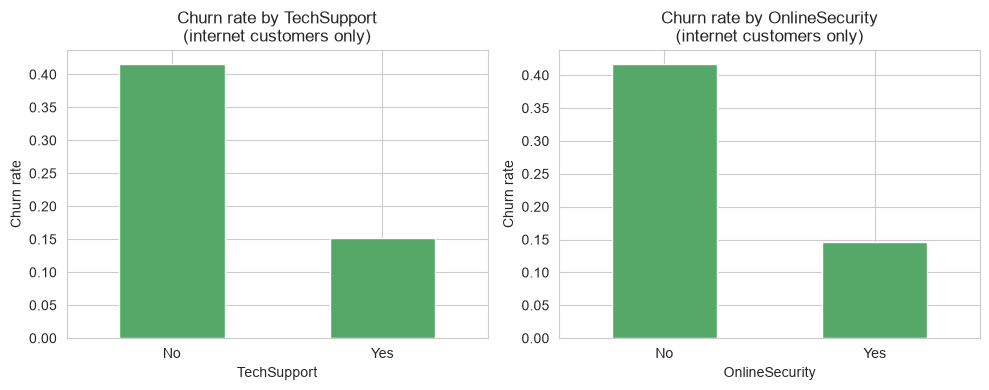

In [19]:
has_internet = df[df["InternetService"] != "No"].copy()
print("Customers with internet:", len(has_internet), "/", len(df))

for col in ["TechSupport", "OnlineSecurity"]:
    rates = has_internet.groupby(col)["Churn_numeric"].mean()
    contingency = pd.crosstab(has_internet[col], has_internet["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"\n{col} churn rate:\n{rates}")
    print(f"chi2 = {chi2:.2f}, p = {p:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["TechSupport", "OnlineSecurity"]):
    has_internet.groupby(col)["Churn_numeric"].mean().plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(f"Churn rate by {col}\n(internet customers only)")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** *(fill in once run on real data)* — note the size
of the gap between "Yes" and "No" for each add-on, and whether both
add-ons move in the same direction. H2 confirmed / contradicted: ___

### 4. H3 — Tenure

**Test:** raw correlation with churn, *and* bucketed churn rate — a single
correlation coefficient can hide a non-linear relationship (e.g. risk
dropping sharply in year one, then flattening), which matters later for
deciding whether tenure needs a transformation before modeling.

Point-biserial correlation (tenure vs churn): -0.352, p = 7.999e-205

Churn rate by tenure bucket:
 tenure_bucket
0-12     0.474382
13-24    0.287109
25-48    0.203890
49-60    0.144231
61-72    0.066098
Name: Churn_numeric, dtype: float64


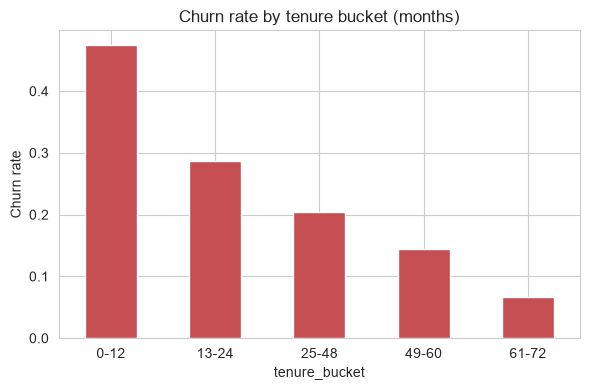

In [20]:
corr, p = pointbiserialr(df["Churn_numeric"], df["tenure"])
print(f"Point-biserial correlation (tenure vs churn): {corr:.3f}, p = {p:.4g}")

bins = [-1, 12, 24, 48, 60, 72]
labels = ["0-12", "13-24", "25-48", "49-60", "61-72"]
df["tenure_bucket"] = pd.cut(df["tenure"], bins=bins, labels=labels)

bucket_rates = df.groupby("tenure_bucket", observed=True)["Churn_numeric"].mean()
print("\nChurn rate by tenure bucket:\n", bucket_rates)

fig, ax = plt.subplots(figsize=(6, 4))
bucket_rates.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by tenure bucket (months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** *(fill in once run on real data)* — note the
correlation sign/strength, and whether the bucketed chart shows a smooth
linear decline or a sharper early drop-off. H3 confirmed / contradicted:
___

### 5. H4 — Monthly charges

**Test:** distribution of `MonthlyCharges` split by churn, plus
correlation.

Point-biserial correlation (MonthlyCharges vs churn): 0.193, p = 2.707e-60


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10704\213849894.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax, palette="Set2")


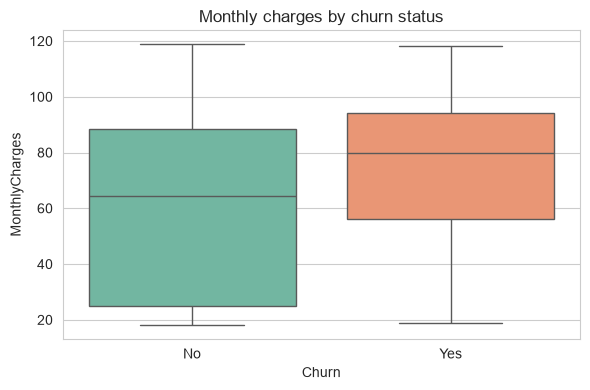

In [21]:
corr, p = pointbiserialr(df["Churn_numeric"], df["MonthlyCharges"])
print(f"Point-biserial correlation (MonthlyCharges vs churn): {corr:.3f}, p = {p:.4g}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax, palette="Set2")
ax.set_title("Monthly charges by churn status")
plt.tight_layout()
plt.show()

**Interpretation:** *(fill in once run on real data)* — note whether
churned customers skew toward higher `MonthlyCharges`, and how strong the
correlation is relative to H1/H3. H4 confirmed / contradicted: ___

### 6. H5 — Internet service type

**Test:** churn rate by `InternetService` category (DSL / Fiber optic /
No), chi-square test.

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn_numeric, dtype: float64

chi2 = 732.31, p = 9.572e-160


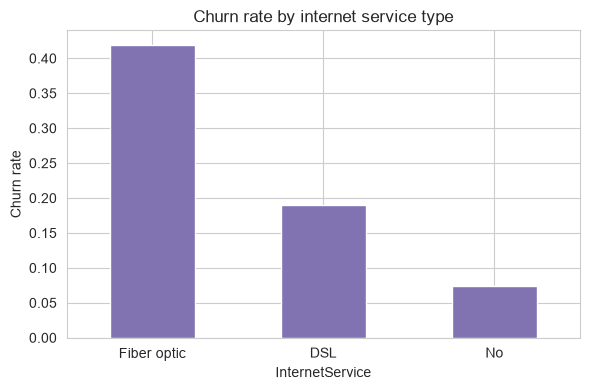

In [22]:
service_rates = df.groupby("InternetService")["Churn_numeric"].mean().sort_values(ascending=False)
print(service_rates)

contingency = pd.crosstab(df["InternetService"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nchi2 = {chi2:.2f}, p = {p:.4g}")

fig, ax = plt.subplots(figsize=(6, 4))
service_rates.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by internet service type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** *(fill in once run on real data)* — note whether
fiber optic customers churn more than DSL, and whether "No internet"
customers (who can't churn on this dimension) sit far below both. H5
confirmed / contradicted: ___

### 7. Correlation heatmap — with the target included

`Churn_numeric` is included deliberately (Decision Point 2, see notebook
intro) — a heatmap built with `select_dtypes(include="number")` *before*
encoding the target would run without error but silently exclude the one
relationship most worth checking.

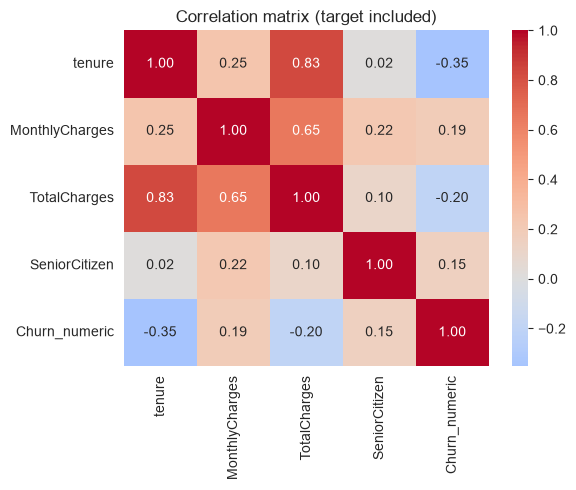

In [23]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_numeric"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (target included)")
plt.tight_layout()
plt.show()

**Note:** `tenure` and `TotalCharges` are very likely to show a
strong correlation with each other here (longer-tenured customers have
naturally paid more in total) — that's a multicollinearity *flag*, not a
decision. It gets resolved with an actual VIF check in the feature
engineering stage, not acted on here.

### 8. Summary

| Hypothesis | Result | Evidence |
|---|---|---|
| H1 — Contract type | ___ | churn rate gap + chi-square p-value above |
| H2 — Support add-ons | ___ | churn rate gap + chi-square p-value above |
| H3 — Tenure | ___ | correlation + bucketed chart shape above |
| H4 — Monthly charges | ___ | correlation + boxplot above |
| H5 — Internet service | ___ | churn rate gap + chi-square p-value above |

Fill in "Confirmed" / "Contradicted" / "Inconclusive" for each once this is
re-run on the real Kaggle CSV. It's fine — expected, even — if not
everything confirms. An EDA notebook where every hypothesis "wins" is a
signal the hypotheses were quietly informed by having already seen the
data, not genuine predictions.

### 9. Explicitly out of scope for this notebook

- No columns are dropped here, even if they look uninformative.
- No new features are engineered from what looks promising (e.g. no
  tenure-bucket-as-a-model-feature decision yet — bucketing above was for
  *seeing* the shape, not for building a pipeline).
- The `SeniorCitizen` (0/1) vs. other categorical columns (`Yes`/`No`)
  encoding inconsistency, flagged in Stage 3, is not fixed here — it gets
  handled once, in one place, during the Stage 6 pipeline.
- The `tenure`/`TotalCharges` multicollinearity flag above is not acted on
  here — it waits for a real VIF check.